=== Model Performance ===
R² Score: 0.9626
MSE: 4.682
RMSE: 2.164
MAE: 1.750


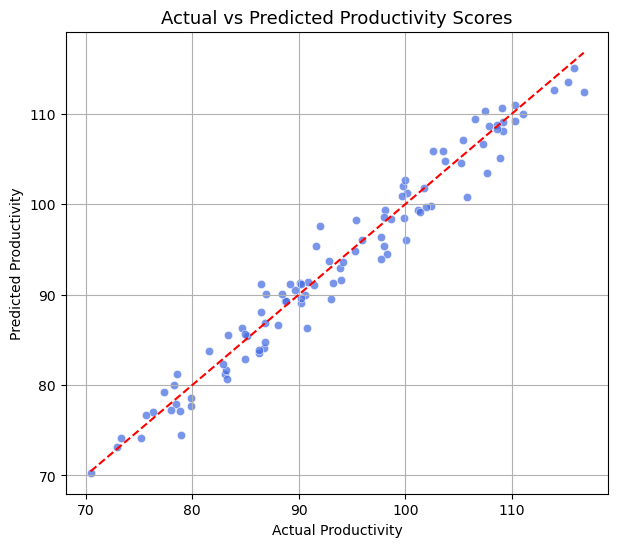

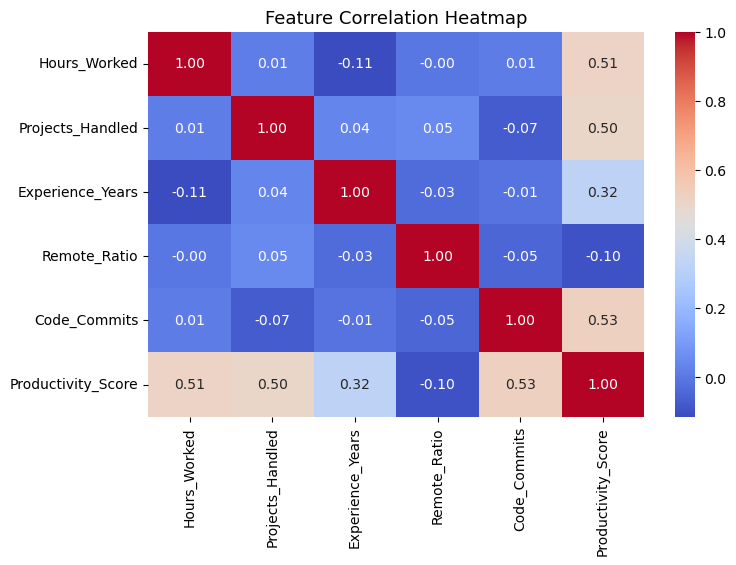

C:\Users\zubae\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
# ================================================================
# Enhanced MLR Model with GUI and Visualization
# Predicting Employee Productivity in IT Firms
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import tkinter as tk
from tkinter import messagebox

# -----------------------------
# 1. Generate Synthetic Dataset
# -----------------------------
np.random.seed(42)
n_samples = 500

hours_worked = np.random.normal(40, 5, n_samples)
projects_handled = np.random.randint(1, 6, n_samples)
experience_years = np.random.normal(5, 2, n_samples)
remote_ratio = np.random.uniform(0, 1, n_samples)
code_commits = np.random.randint(10, 100, n_samples)

# reduce noise for higher R²
noise = np.random.normal(0, 2, n_samples)

# Productivity formula with stronger linear relation
productivity_score = (
    1.2 * hours_worked +
    4.0 * projects_handled +
    2.0 * experience_years -
    3.0 * remote_ratio +
    0.25 * code_commits +
    10 + noise
)

df = pd.DataFrame({
    'Hours_Worked': hours_worked,
    'Projects_Handled': projects_handled,
    'Experience_Years': experience_years,
    'Remote_Ratio': remote_ratio,
    'Code_Commits': code_commits,
    'Productivity_Score': productivity_score
})

# -----------------------------
# 2. Train the MLR Model
# -----------------------------
X = df[['Hours_Worked', 'Projects_Handled', 'Experience_Years', 'Remote_Ratio', 'Code_Commits']]
y = df['Productivity_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# -----------------------------
# 3. Model Evaluation
# -----------------------------
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print("=== Model Performance ===")
print(f"R² Score: {r2:.4f}")
print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")

# -----------------------------
# 4. Visualization
# -----------------------------
plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='royalblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Actual vs Predicted Productivity Scores", fontsize=13)
plt.xlabel("Actual Productivity")
plt.ylabel("Predicted Productivity")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap", fontsize=13)
plt.show()

# -----------------------------
# 5. Build and Launch GUI
# -----------------------------
root = tk.Tk()
root.title("Employee Productivity Predictor")
root.geometry("420x420")
root.config(bg="#f0f4f7")

tk.Label(root, text="Employee Productivity Predictor", font=("Arial", 14, "bold"), bg="#f0f4f7").pack(pady=10)

frame = tk.Frame(root, bg="#f0f4f7")
frame.pack(pady=10)

labels = [
    "Hours Worked (per week)",
    "Projects Handled",
    "Experience (years)",
    "Remote Ratio (0–1)",
    "Code Commits (per month)"
]

entries = []

for text in labels:
    tk.Label(frame, text=text, font=("Arial", 10), bg="#f0f4f7").pack()
    entry = tk.Entry(frame, width=25, font=("Arial", 10))
    entry.pack(pady=3)
    entries.append(entry)

def predict_productivity():
    try:
        hw = float(entries[0].get())
        ph = float(entries[1].get())
        exp = float(entries[2].get())
        rr = float(entries[3].get())
        cc = float(entries[4].get())

        input_data = np.array([[hw, ph, exp, rr, cc]])
        prediction = model.predict(input_data)[0]

        messagebox.showinfo(
            "Prediction Result",
            f"Predicted Productivity Score: {prediction:.2f}\n\n"
            f"(Model R²: {r2:.3f}, RMSE: {rmse:.2f})"
        )

    except ValueError:
        messagebox.showerror("Input Error", "Please enter valid numeric values.")

tk.Button(root, text="Predict Productivity", command=predict_productivity,
          font=("Arial", 11, "bold"), bg="#2c7be5", fg="white",
          relief="raised", padx=10, pady=5).pack(pady=15)

tk.Button(root, text="Exit", command=root.destroy,
          font=("Arial", 10), bg="gray", fg="white",
          relief="groove", padx=8, pady=3).pack(pady=5)

root.mainloop()
